# Assignment 3 — Task 1 & Task 2: CNN for Facade Defect Classification
**CE 639: AI for Civil Engineering | IIT Gandhinagar**

## Task 1: Understanding the Problem

### What is the classification problem?
The FBD (Facade Building Defects) dataset contains **1591 images** of building facades collected from three Italian cities. Each image is resized to **224×224 pixels** and labeled into one of **four defect classes**: Crack, Spalling, Stain, and Vegetation. The goal is to train a CNN that can automatically classify which type of defect appears in a given facade image.

| Class | Train | Test | Total |
|-------|-------|------|-------|
| Crack | 232 | 58 | 290 |
| Spalling | 436 | 109 | 545 |
| Stain | 422 | 106 | 528 |
| Vegetation | 182 | 46 | 228 |

In [1]:
DATA_DIR = "./FBD-Dataset-main/train-test-split" 
BATCH_SIZE = 64
EPOCHS = 25
LR = 0.001
SEED = 42

In [2]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Step 1: Load the .npy Data

In [3]:
X_train = np.load(os.path.join(DATA_DIR, "training_images.npy"))      # shape: (N, H, W, C) or (N, C, H, W)
y_train = np.load(os.path.join(DATA_DIR, "training_labels.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "validation_images.npy"))
y_val   = np.load(os.path.join(DATA_DIR, "validation_labels.npy"))

print("Train images:", X_train.shape, "| Labels:", y_train.shape)
print("Val images:  ", X_val.shape,   "| Labels:", y_val.shape)
print("Pixel range: ", X_train.min(), "to", X_train.max())

CLASS_NAMES = ["Crack", "Spalling", "Stain", "Vegetation"]
# print(y_train[0:10])

Train images: (1272, 224, 224, 3) | Labels: (1272,)
Val images:   (319, 224, 224, 3) | Labels: (319,)
Pixel range:  0 to 255


In [4]:
# Normalise to [0, 1] and convert to (N, C, H, W) if needed
def prepare(X, y):
    X = X.astype(np.float32)
    if X.max() > 1.0:           # pixel values in [0, 255]
        X = X / 255.0
    if X.ndim == 4 and X.shape[-1] == 3:   # (N,H,W,C) → (N,C,H,W)
        X = X.transpose(0, 3, 1, 2)
    # ImageNet normalisation
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1,3,1,1)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1,3,1,1)
    X = (X - mean) / std
    y = y.astype(np.int64)
    if y.ndim > 1:              # one-hot → class index
        y = np.argmax(y, axis=1)
    return torch.tensor(X), torch.tensor(y)

X_train_t, y_train_t = prepare(X_train, y_train)
X_val_t,   y_val_t   = prepare(X_val,   y_val)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
print("Loaders ready. Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Loaders ready. Train batches: 20 | Val batches: 5


## Task 1 — Show One Example Image per Class

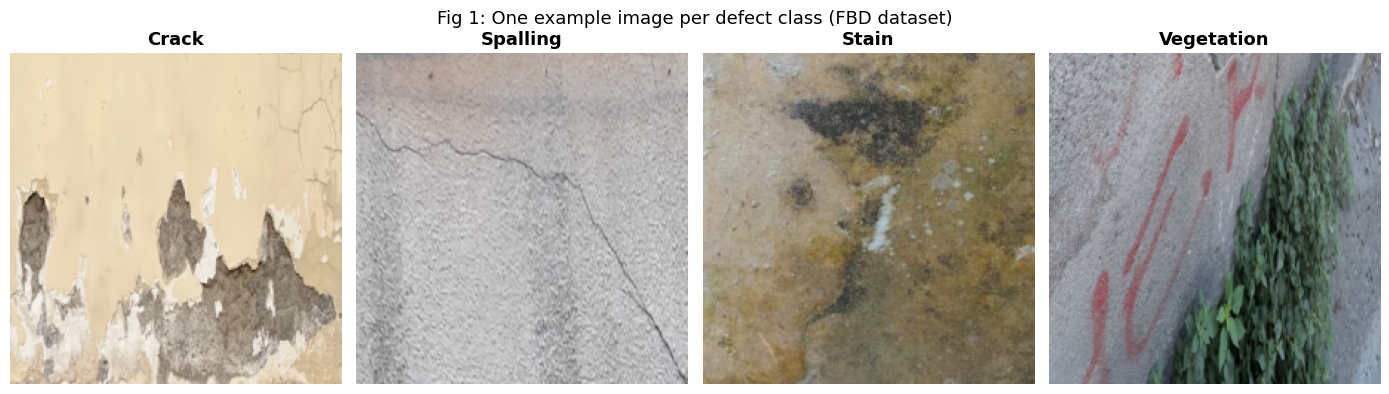

Saved: task1_example_images.png


In [5]:
# For display we use raw (un-normalised) pixel values
def to_display(X_raw):
    X = X_raw.astype(np.float32)
    if X.max() > 1.0:
        X = X / 255.0
    if X.ndim == 3 and X.shape[0] == 3:   # (C,H,W) → (H,W,C)
        X = X.transpose(1, 2, 0)
    return np.clip(X, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
labels_raw = y_train
if labels_raw.ndim > 1:
    labels_raw = np.argmax(labels_raw, axis=1)

for i, cls_name in enumerate(CLASS_NAMES):
    idx = np.where(labels_raw == i)[0][0]
    img = to_display(X_train[idx])
    axes[i].imshow(img)
    axes[i].set_title(cls_name, fontsize=13, fontweight='bold')
    axes[i].axis('off')

fig.suptitle("Fig 1: One example image per defect class (FBD dataset)", fontsize=13)
plt.tight_layout()
plt.savefig("task1_example_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task1_example_images.png")

## Task 2: Build and Train the CNN

In [6]:
class CNN(nn.Module):
    """
    Simple 3-block CNN for 4-class facade defect classification.
    Input: (B, 3, 224, 224)
    Block 1: Conv(3→16, 3x3) → BN → ReLU → MaxPool  → 112x112
    Block 2: Conv(16→32, 3x3) → BN → ReLU → MaxPool → 56x56
    Block 3: Conv(32→64, 3x3) → BN → ReLU → MaxPool → 28x28
    FC: 64*28*28 → 256 → Dropout(0.5) → 4
    """
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 112x112
            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 56x56
            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 28x28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=256, bias=True)
  

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses, val_losses, val_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)   # per-batch average

    # ── Validation ──
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Epoch   1/25 | Train Loss: 8.9472 | Val Loss: 1.6949 | Val Acc: 45.45%
Epoch   5/25 | Train Loss: 1.0354 | Val Loss: 1.0185 | Val Acc: 54.86%
Epoch  10/25 | Train Loss: 0.9557 | Val Loss: 0.9766 | Val Acc: 55.49%
Epoch  15/25 | Train Loss: 0.8619 | Val Loss: 0.9729 | Val Acc: 57.37%
Epoch  20/25 | Train Loss: 0.7752 | Val Loss: 0.9720 | Val Acc: 57.37%
Epoch  25/25 | Train Loss: 0.7268 | Val Loss: 0.9497 | Val Acc: 59.56%


## Plot: Training & Validation Loss Curve + Accuracy

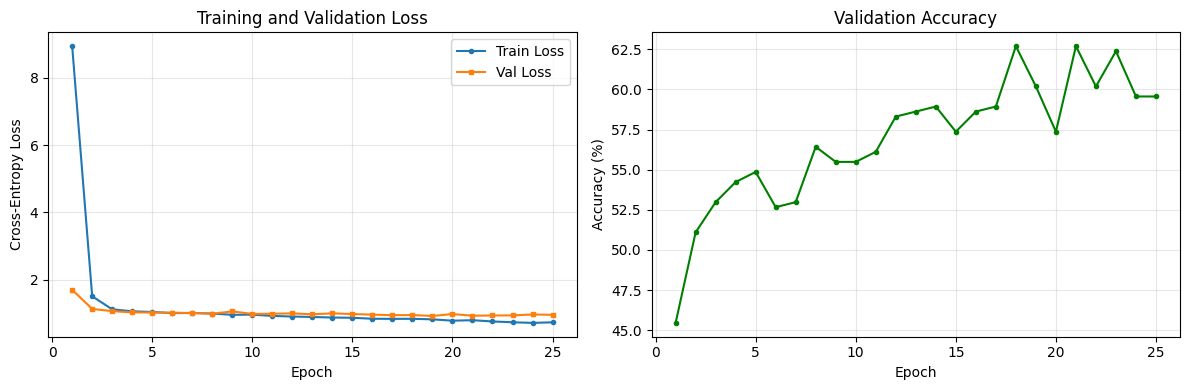

Final Validation Accuracy: 59.56%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, train_losses, label="Train Loss", marker='o', markersize=3)
ax1.plot(epochs_range, val_losses,   label="Val Loss",   marker='s', markersize=3)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in val_accs], color='green', marker='o', markersize=3)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Validation Accuracy")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("task2_loss_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Final Validation Accuracy: {val_accs[-1]*100:.2f}%")

## Evaluation: Confusion Matrix & Classification Report

In [9]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Crack       0.52      0.77      0.62       109
    Spalling       0.62      0.22      0.33        58
       Stain       0.64      0.55      0.59       106
  Vegetation       0.76      0.76      0.76        46

    accuracy                           0.60       319
   macro avg       0.64      0.58      0.58       319
weighted avg       0.61      0.60      0.58       319



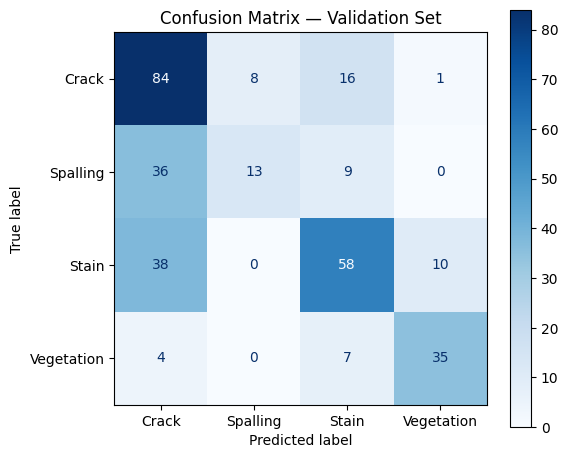

In [10]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Validation Set")
plt.tight_layout()
plt.savefig("task2_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## Show 4 Predicted Validation Examples

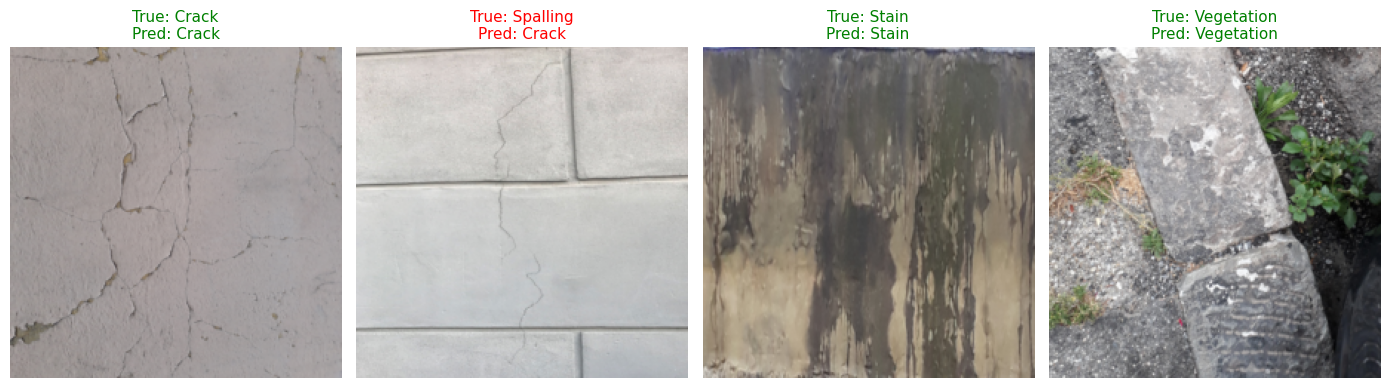

In [12]:
# Pick one example per class from the validation set
labels_val_raw = y_val
if labels_val_raw.ndim > 1:
    labels_val_raw = np.argmax(labels_val_raw, axis=1)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
model.eval()

for i, cls_name in enumerate(CLASS_NAMES):
    idx = np.where(labels_val_raw == i)[0][0]
    img_tensor = X_val_t[idx].unsqueeze(0).to(device)
    with torch.no_grad():
        pred_class = torch.argmax(model(img_tensor), dim=1).item()

    img_display = to_display(X_val[idx])
    axes[i].imshow(img_display)
    color = 'green' if pred_class == i else 'red'
    axes[i].set_title(
        f"True: {CLASS_NAMES[i]}\nPred: {CLASS_NAMES[pred_class]}",
        color=color, fontsize=11
    )
    axes[i].axis('off')

#fig.suptitle("Fig 2: Predicted vs True labels for 4 validation images (green=correct, red=wrong)", fontsize=11)
plt.tight_layout()
plt.savefig("task2_predicted_examples.png", dpi=150, bbox_inches='tight')
plt.show()

## Discussion: Easy and Difficult Classes

**Easy classes:** Vegetation tends to be easiest because it has a distinct visual signature — green biological growth on grey/beige facades is highly separable from the other classes.

**Difficult classes:** Crack and Spalling are often confused because spalling involves surface detachment which can look like a large crack. Stain may also be confused with Spalling when discolouration accompanies surface detachment. The class imbalance (Crack has only 232 training images vs 436 for Spalling) further hurts Crack recall.